# Notebook 9: Testing a Language Model on Your Own Task (Benchmark)

**Who this is for:** Digital Humanities students with no prior AI or programming background.

**What you will learn**
1. What a **benchmark** is: a test with answers you trust, and a score
2. How to measure how often a model is right (accuracy), in English and in Arabic
3. How to see **which mistakes** the model makes
4. How to compare two prompts fairly

**Before you start:** turn on the free GPU (*Runtime > Change runtime type > T4 GPU > Save*). We use the free open-weight model from Notebook 6. The same code works for an API model: replace the `ask()` function with the one from Notebook 3 or 4. Lines that start with `#` are comments for humans.

## 0. Setup

In [1]:
# Check that we have a GPU, and install the tools we need.
import torch
print("GPU found:" if torch.cuda.is_available() else "No GPU. Turn it on in Runtime > Change runtime type.",
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")

# "!" runs a system command. This takes about a minute.
!pip install -q -U transformers accelerate

GPU found: Tesla T4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 74.5 MB/s eta 0:00:00


In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM

# Qwen is open: no account and no token are needed (see Notebook 6 for the details).
MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"

# The tokenizer cuts text into small pieces ("tokens"); the model reads and writes them.
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

# The first run downloads about 6 GB (a few minutes).
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float16, device_map="auto")
print("Model loaded:", MODEL_ID)

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded: Qwen/Qwen2.5-3B-Instruct


In [3]:
def ask(prompt, system=None, max_tokens=300):
    """Send a question to the local model and return its answer.
    The model always picks its most likely words, so the same question gives the same answer."""
    messages = []
    if system:
        messages.append({"role": "system", "content": system})
    messages.append({"role": "user", "content": prompt})

    # Turn the conversation into tokens and move them to the GPU.
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt", add_special_tokens=False).to(model.device)

    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=max_tokens, do_sample=False,
                                temperature=None, top_p=None, top_k=None,
                                pad_token_id=tokenizer.eos_token_id)

    # Keep only the new words (not our question) and turn them back into text.
    return tokenizer.decode(output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

print(ask("Reply with one word: ready", max_tokens=10))

ready


## 1. The idea

Before using a model on thousands of documents, **test it on a small sample where you already know the right answer**. A simple benchmark has four steps:

1. **Collect** examples and write the correct answer for each (the *gold label*).
2. **Run** the model on the same examples.
3. **Compare** the model's answers with the gold labels and compute a score.
4. **Look at the mistakes**, improve the prompt, and test again.

Our task is **sentiment**: is a comment about a digital archive POSITIVE, NEGATIVE or NEUTRAL? We use 24 short comments: 12 English and 12 Arabic (4 of each label per language). They are **invented** for this exercise, and we wrote the gold labels ourselves.

In [4]:
#@title Load the 24 labelled comments (double-click to show the code) { display-mode: "form" }
TEST_SET = [
    {"language": "en", "text": "The digital archive saved me weeks of work.", "gold": "POSITIVE"},
    {"language": "en", "text": "Excellent collection, and the search is fast and easy.", "gold": "POSITIVE"},
    {"language": "en", "text": "I finally found the letter I was looking for. Wonderful!", "gold": "POSITIVE"},
    {"language": "en", "text": "The scans are clear and the catalogue is very well organised.", "gold": "POSITIVE"},
    {"language": "en", "text": "The search is slow and the results are inaccurate.", "gold": "NEGATIVE"},
    {"language": "en", "text": "Half of the pages will not load, and nobody answers emails.", "gold": "NEGATIVE"},
    {"language": "en", "text": "The scans are so blurry that the text cannot be read.", "gold": "NEGATIVE"},
    {"language": "en", "text": "Very disappointing, most of the material is not available online.", "gold": "NEGATIVE"},
    {"language": "en", "text": "New manuscripts were uploaded on Sunday.", "gold": "NEUTRAL"},
    {"language": "en", "text": "The reading room is open from nine to five.", "gold": "NEUTRAL"},
    {"language": "en", "text": "The website has one section for newspapers and one for maps.", "gold": "NEUTRAL"},
    {"language": "en", "text": "The centre will hold a workshop on cataloguing next week.", "gold": "NEUTRAL"},
    {"language": "ar", "text": "الأرشيف الرقمي ساعدني كثيرا في بحثي", "gold": "POSITIVE"},
    {"language": "ar", "text": "موقع رائع وسهل الاستخدام، شكرا لكم", "gold": "POSITIVE"},
    {"language": "ar", "text": "وجدت المخطوطة التي كنت أبحث عنها منذ سنوات", "gold": "POSITIVE"},
    {"language": "ar", "text": "الصور واضحة جدا والفهرسة ممتازة", "gold": "POSITIVE"},
    {"language": "ar", "text": "البحث في الموقع بطيء والنتائج غير دقيقة", "gold": "NEGATIVE"},
    {"language": "ar", "text": "الصفحات لا تفتح وخدمة الدعم لا ترد", "gold": "NEGATIVE"},
    {"language": "ar", "text": "جودة المسح سيئة ولا يمكن قراءة النص", "gold": "NEGATIVE"},
    {"language": "ar", "text": "خيبة أمل كبيرة، معظم المواد غير متاحة", "gold": "NEGATIVE"},
    {"language": "ar", "text": "تم رفع المخطوطات الجديدة يوم الأحد", "gold": "NEUTRAL"},
    {"language": "ar", "text": "يفتح الأرشيف أبوابه من التاسعة إلى الخامسة", "gold": "NEUTRAL"},
    {"language": "ar", "text": "الموقع يحتوي على قسم للصحف وقسم للخرائط", "gold": "NEUTRAL"},
    {"language": "ar", "text": "سيعقد المركز ورشة عن الفهرسة الأسبوع القادم", "gold": "NEUTRAL"},
]

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# A quick look at the test set.
display(pd.DataFrame(TEST_SET).head(6))
print(len(TEST_SET), "comments in total")

,language,text,gold
0,en,The digital archive saved me weeks of work.,POSITIVE
1,en,"Excellent collection, and the search is fast a...",POSITIVE
2,en,I finally found the letter I was looking for. ...,POSITIVE
3,en,The scans are clear and the catalogue is very ...,POSITIVE
4,en,The search is slow and the results are inaccur...,NEGATIVE
5,en,"Half of the pages will not load, and nobody an...",NEGATIVE


24 comments in total


## 2. Prompt A: a simple instruction

The function `predict()` sends one comment to the model and reads the label in its answer. If the answer contains no valid label, we record `INVALID`: a model that does not follow the format is also a result worth knowing.

In [6]:
LABELS = ["POSITIVE", "NEGATIVE", "NEUTRAL"]

PROMPT_A = (
    "Classify the sentiment of this comment about a digital archive as POSITIVE, NEGATIVE or NEUTRAL.\n"
    "Answer with the label only.\n\n"
    "Comment: {text}\n"
    "Label:"
)

def predict(text, template):
    """Ask the model for a label and return the first valid label found in its answer."""
    answer = ask(template.format(text=text), max_tokens=8).upper()   # {text} is replaced by the comment
    for label in LABELS:
        if label in answer:
            return label
    return "INVALID"                                                 # no usable label in the answer

def evaluate(template):
    """Run the model on the whole test set and return one row per comment."""
    rows = []
    for item in TEST_SET:
        predicted = predict(item["text"], template)
        rows.append({"language": item["language"], "text": item["text"], "gold": item["gold"],
                     "predicted": predicted, "correct": predicted == item["gold"]})
    return pd.DataFrame(rows)

results_a = evaluate(PROMPT_A)         # takes about a minute
display(results_a.head(6))

,language,text,gold,predicted,correct
0,en,The digital archive saved me weeks of work.,POSITIVE,POSITIVE,True
1,en,"Excellent collection, and the search is fast a...",POSITIVE,POSITIVE,True
2,en,I finally found the letter I was looking for. ...,POSITIVE,POSITIVE,True
3,en,The scans are clear and the catalogue is very ...,POSITIVE,POSITIVE,True
4,en,The search is slow and the results are inaccur...,NEGATIVE,NEGATIVE,True
5,en,"Half of the pages will not load, and nobody an...",NEGATIVE,NEGATIVE,True


## 3. The score

**Accuracy** = the share of comments where the model's label equals the gold label.

In [7]:
def accuracy_table(results):
    """Accuracy overall and per language, in percent."""
    return pd.Series({
        "All": results["correct"].mean() * 100,
        "English": results[results["language"] == "en"]["correct"].mean() * 100,
        "Arabic": results[results["language"] == "ar"]["correct"].mean() * 100,
    }).round(1)

print("Prompt A, accuracy in %:")
print(accuracy_table(results_a))

Prompt A, accuracy in %:
All         95.8
English    100.0
Arabic      91.7
dtype: float64


## 4. Which mistakes?

A score hides **what kind** of mistake the model makes. A *confusion matrix* shows it: rows are the gold labels, columns are the model's answers. The diagonal (top left to bottom right) holds the correct answers.

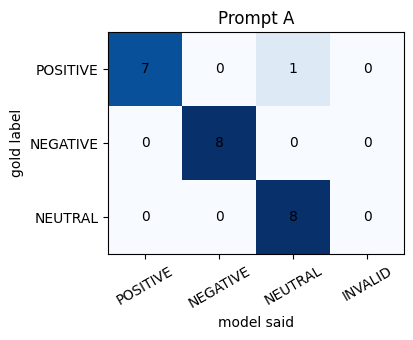

In [8]:
def draw_confusion(results, title):
    """Draw gold labels (rows) against the model's labels (columns)."""
    table = pd.crosstab(results["gold"], results["predicted"])
    table = table.reindex(index=LABELS, columns=LABELS + ["INVALID"], fill_value=0)

    plt.figure(figsize=(5, 3.5))
    plt.imshow(table.values, cmap="Blues")
    plt.xticks(range(len(table.columns)), table.columns, rotation=30)
    plt.yticks(range(len(table.index)), table.index)
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            plt.text(j, i, table.values[i, j], ha="center", va="center")   # the count in each cell
    plt.xlabel("model said")
    plt.ylabel("gold label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

draw_confusion(results_a, "Prompt A")

In [9]:
# The mistakes, one by one: read them and ask yourself why the model got them wrong.
display(results_a[~results_a["correct"]][["language", "text", "gold", "predicted"]])

,language,text,gold,predicted
14,ar,وجدت المخطوطة التي كنت أبحث عنها منذ سنوات,POSITIVE,NEUTRAL


## 5. Prompt B: definitions and examples

Can a better prompt help? Prompt B **defines** each label and adds **three examples** (few-shot, as in Notebook 3). We change only the prompt, and we use the same test set, so the comparison is fair. The examples are not in the test set.

Prompt B, accuracy in %:
All        100.0
English    100.0
Arabic     100.0
dtype: float64


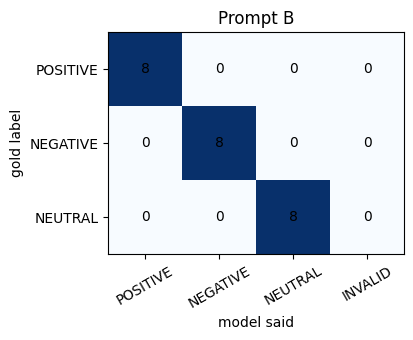

In [10]:
PROMPT_B = (
    "Classify the sentiment of a comment about a digital archive.\n"
    "POSITIVE = the writer is pleased or grateful.\n"
    "NEGATIVE = the writer complains or is disappointed.\n"
    "NEUTRAL = the comment only gives information, with no opinion.\n"
    "Answer with the label only.\n\n"
    'Comment: "The scans are excellent, thank you!"\nLabel: POSITIVE\n\n'
    'Comment: "لم أستطع فتح أي ملف"\nLabel: NEGATIVE\n\n'
    'Comment: "The archive adds new letters every Friday."\nLabel: NEUTRAL\n\n'
    "Comment: {text}\n"
    "Label:"
)

results_b = evaluate(PROMPT_B)

print("Prompt B, accuracy in %:")
print(accuracy_table(results_b))
draw_confusion(results_b, "Prompt B")

## 6. Comparing the two prompts

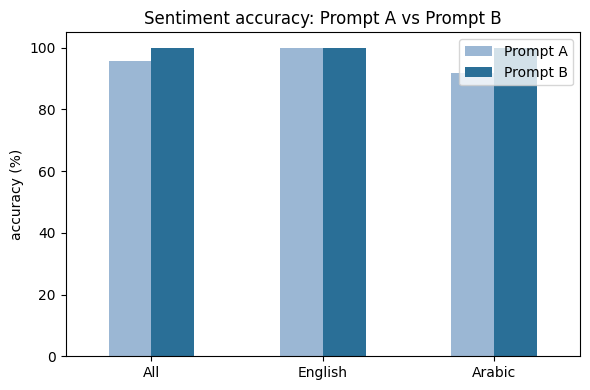

,Prompt A,Prompt B
All,95.8,100.0
English,100.0,100.0
Arabic,91.7,100.0


In [11]:
summary = pd.DataFrame({"Prompt A": accuracy_table(results_a), "Prompt B": accuracy_table(results_b)})

summary.plot(kind="bar", figsize=(6, 4), rot=0, color=["#9bb7d4", "#2a6f97"])
plt.ylabel("accuracy (%)")
plt.ylim(0, 105)
plt.title("Sentiment accuracy: Prompt A vs Prompt B")
plt.tight_layout()
plt.show()

summary

## 7. Reading the results with care

- **Our test set is small.** With 24 comments, one comment is worth about 4 percentage points. A difference of 1 or 2 comments between two prompts is **not** evidence. For real research use at least 100 comments, and report the numbers per language.
- **Gold labels are human decisions.** Real projects use two or more annotators and report how often they agree. Some comments are genuinely ambiguous.
- **Our comments are easy and invented.** Real historical, literary or dialectal text is harder. Build your test set from **your own material**.
- **Record everything:** the model name, the exact prompt, the date, the test set and the scores.
- **Another model?** Replace `ask()` and run the same cells. This is how you compare models fairly.

## Key takeaways

- A **benchmark** is a test set with gold labels and a score. Build a small one for **your own task** before trusting a model.
- Accuracy is a start. The **mistakes** (confusion matrix, error table) tell you what to fix.
- Change **one thing at a time** (the prompt, or the model) and keep the test set fixed.

## Exercises

1. Add 4 comments from your own research area (two Arabic, two English) with gold labels. Does the accuracy change?
2. Write a Prompt C of your own. Does it beat Prompt B?
3. Change the task: label the **document type** (LETTER, NEWSPAPER, POEM) as in Notebook 3, and build a new test set of 15 snippets.

**You have now finished the series.** You can embed and search texts, store them in a vector database, prompt models through an API or on your own GPU, answer questions from documents with RAG, run common research tasks, and test a model before trusting it.